## LeNet

In [1]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Flatten, Conv2D,AveragePooling2D
from keras.models import Sequential
from keras.datasets import mnist

In [2]:
(X_train,y_train),(X_test,y_test)=keras.datasets.mnist.load_data()

In [3]:
# LeNet Achitecture

model = Sequential()
model.add(Conv2D(6,kernel_size=(5,5),padding='valid',activation='tanh',input_shape=(28,28,1)))
model.add(AveragePooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(16,kernel_size=(5,5),padding='valid',activation='tanh'))
model.add(AveragePooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(120,activation='tanh'))
model.add(Dense(84,activation='tanh'))
model.add(Dense(10,activation='softmax'))

d:\Programming\Deep_Learning_Concept\.tensorli\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

model.fit(X_train.reshape(-1,28,28,1), y_train, epochs=10, batch_size=64, validation_data=(X_test.reshape(-1,28,28,1), y_test))

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8909 - loss: 0.3912 - val_accuracy: 0.9785 - val_loss: 0.0652
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9763 - loss: 0.0776 - val_accuracy: 0.9817 - val_loss: 0.0556
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9827 - loss: 0.0554 - val_accuracy: 0.9865 - val_loss: 0.0418
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9871 - loss: 0.0398 - val_accuracy: 0.9826 - val_loss: 0.0511
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9895 - loss: 0.0353 - val_accuracy: 0.9823 - val_loss: 0.0503
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9904 - loss: 0.0303 - val_accuracy: 0.9886 - val_loss: 0.0318
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9919 - loss: 0.0249 - val_accuracy: 0.9892 - val_loss: 0.0307
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9934 - loss: 0.0197 - val_accuracy: 0.

In [6]:
model.history.history

{'accuracy': [0.9465833306312561,
  0.9781666398048401,
  0.9831833243370056,
  0.9863666892051697,
  0.9889666438102722,
  0.9902499914169312,
  0.9918000102043152,
  0.9928666949272156,
  0.9941666722297668,
  0.9938333630561829],
 'loss': [0.18707728385925293,
  0.07143751531839371,
  0.05246243625879288,
  0.04220180585980415,
  0.03575768694281578,
  0.031252868473529816,
  0.025862066075205803,
  0.022293394431471825,
  0.018928885459899902,
  0.01890149898827076],
 'val_accuracy': [0.9785000085830688,
  0.9817000031471252,
  0.9865000247955322,
  0.9825999736785889,
  0.9822999835014343,
  0.9886000156402588,
  0.9891999959945679,
  0.9890000224113464,
  0.9872000217437744,
  0.9896000027656555],
 'val_loss': [0.06523872911930084,
  0.055588457733392715,
  0.04184022918343544,
  0.05111578851938248,
  0.05026944726705551,
  0.031800996512174606,
  0.030727917328476906,
  0.033565226942300797,
  0.040918461978435516,
  0.034902073442935944]}

In [7]:
# %pip install matplotlib
# %pip install scikit-learn
# %pip install seaborn

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

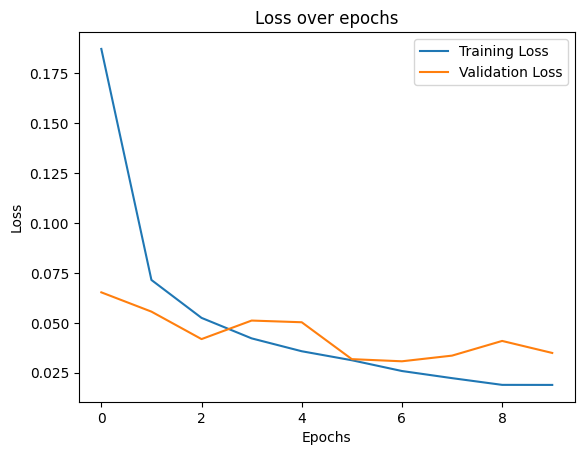

In [9]:
plt.plot(model.history.history['loss'], label='Training Loss')
plt.plot(model.history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()
